In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def frameBuilder(path="./live-data"):
    cols = pd.read_csv("header.csv").columns.tolist()
    data = Path(path).glob("trade*.csv")
    df = pd.concat(
    (pd.read_csv(f, skiprows=1, header=None, names=cols) for f in data),
    ignore_index=True)
    return df

# errors: 13
Pnl: -10.508509999999996
Optimal entry: 48
Entries: 455; wins: 445; losses: 10; pnl: 17.34868 


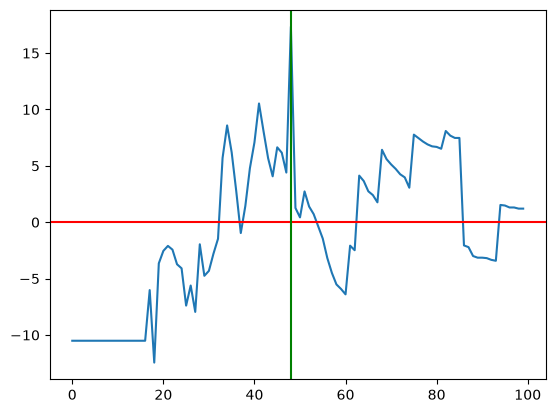

In [15]:
df = frameBuilder()
pre = len(df)
df = df[df.post_error.isna()]

print(f"# errors: {pre - len(df)}")
print(f"Pnl: {df.realized_pnl.sum()}")

fig = plt.figure()
x = np.arange(0,100)
y = np.zeros(100)
for i in range(100):
    y[i] = df[abs(df.price_diff_from_entry)>=x[i]].realized_pnl.sum()
optimal_entry = np.argmax(y)

plt.plot(x, y)
plt.axhline(y=0, color='r')
plt.axvline(x=optimal_entry, color='g')


print(f"Optimal entry: {optimal_entry}")
optimal = df[abs(df.price_diff_from_entry) >= optimal_entry]
print(f"Entries: {len(optimal)}; wins: {len(optimal[optimal.won==1])}; losses: {len(optimal[optimal.won==0])}; pnl: {optimal.realized_pnl.sum()} ")


,window_start_ts,period_of_day,condition_id,side,order_id,intended_ask,size_shares,size_matched,notional_target,entry_offset_s,swing_at_entry,btc_at_entry,post_status,post_error,target_pyth,final_pyth,price_diff_from_entry,resolved_side,won,realized_pnl
8,1783486800,60,0x6013ac273d43c7fa8833739a4feb51ff430de1184ba7...,YES,0x588f134799f424bda549c4f9584456d5eb24073bccaa...,0.96,5.21,5.21,5,248,0.26,62779.360,Live,NaN,62746.394493,62743.422424,32.965507,NO,0,-5.0016
13,1783488600,66,0xe1ba108f06c7090099c02b61c7185cb7b7bfcdd7485b...,NO,0x8ace6038087bd2819a09c77cf54eddff17832643ba7b...,0.96,5.21,5.21,5,241,0.10,62674.085,Matched,NaN,62721.135030,62723.062649,-47.050030,YES,0,-5.0016
50,1783528500,199,0xc0e61328ba7c9f5a9f4086c309a230c9cc270cfda208...,NO,0x9219f585a0d4c4c3a21e6f42ec4c7675ca384a364aaf...,0.96,5.21,5.21,5,249,0.05,61749.520,Matched,NaN,61789.842804,61832.480000,-40.322804,YES,0,-5.0016
87,1783548900,267,0x78e09e6625fe6066e6f6d352b91afe35d096ae935b47...,NO,0x3de60299446a4985dbea5e964ae1771d342d73ab3a0d...,0.96,5.21,5.21,5,244,-0.04,62135.300,Matched,NaN,62161.088759,62158.343329,-25.788759,YES,0,-5.0016
120,1783563600,28,0x823060f01fe4740bf9f698a4e9a1d393d30042532ee8...,NO,0xb7421d4dedaec59d250fd3ab17a1b01af87c21ad6359...,0.96,5.21,5.21,5,260,0.52,61987.040,Matched,NaN,62009.455000,62022.375136,-22.415000,YES,0,-5.0016
138,1783573200,60,0xbcf8f81655d35704b1409c37482a7d68967385c013fb...,NO,0x54ec30bc2590ec7693c38b498e7dd0e4a95db75d0b58...,0.98,5.10,5.10,5,269,0.08,62355.500,Matched,NaN,62393.436916,62399.035227,-37.936916,YES,0,-4.9980
139,1783573500,61,0x1e1731365af2671028c014faed77495e982ac22a2cad...,NO,0x5021171bbfd6e99f4bc7ea86a7cc45bf5fa34b843789...,0.96,5.21,5.21,5,274,0.11,62352.010,Live,NaN,62399.402528,62407.312674,-47.392527,YES,0,-5.0016
153,1783580400,84,0x58a281e90c9c61535598e4d650b70d6b2d78ec60dcda...,YES,0x2c039e323a86d2b618ebdc368f62147d23b3bcef0823...,0.96,5.21,5.21,5,288,0.09,62924.860,Live,NaN,62904.231479,62898.972826,20.628521,NO,0,-5.0016
216,1783611000,186,0xc9278800f585bdd52d975f586a0121aa212f7b128566...,YES,0x0fa09567aee362d504c22bc98c3313851aa759069dd9...,0.96,5.21,5.21,5,276,0.03,62965.135,Matched,NaN,62936.015030,62929.080000,29.119970,NO,0,-5.0016
266,1783634700,265,0xc6014b80e7d7439b75d3fff37a48e8ef081e08e64a6c...,YES,0x8f77efcc412b8fd49d971f43df1f550d9163ba504b56...,0.97,5.15,5.15,5,260,0.11,63261.010,Matched,NaN,63242.730000,63245.100000,18.280000,NO,0,-4.9955


Text(0.5, 0, '$ Price difference')

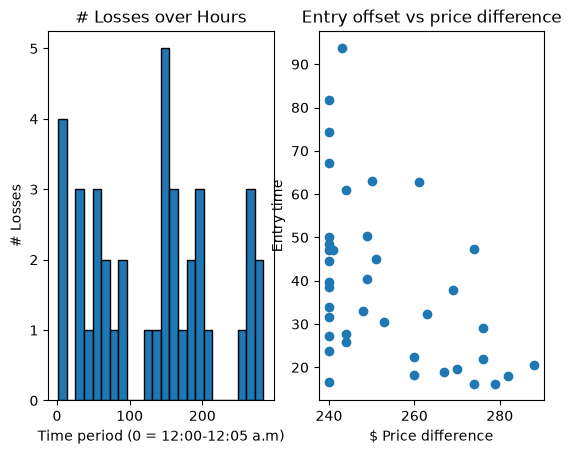

In [16]:
# What went wrong
losses = df[df.won==0]

display(losses)

fig, ax = plt.subplots(1, 2)

# Period of day
ax[0].hist(losses.period_of_day, bins=24, edgecolor='black')
ax[0].set_title("# Losses over Hours")
ax[0].set_ylabel("# Losses")
ax[0].set_xlabel("Time period (0 = 12:00-12:05 a.m)")

# Price difference
ax[1].scatter(losses.entry_offset_s, abs(losses.price_diff_from_entry))
ax[1].set_title("Entry offset vs price difference")
ax[1].set_ylabel("Entry time")
ax[1].set_xlabel("$ Price difference")

Text(0.5, 0, '$ Price difference')

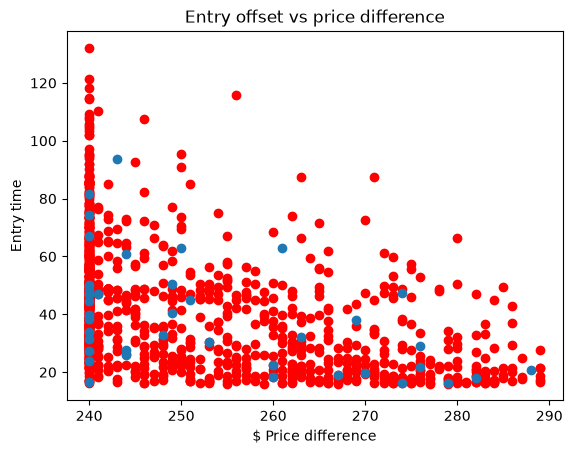

In [17]:
wins = df[df.won==1]

fig, ax = plt.subplots(1)

ax.scatter(wins.entry_offset_s, abs(wins.price_diff_from_entry), color="r")
ax.scatter(losses.entry_offset_s, abs(losses.price_diff_from_entry))
ax.set_title("Entry offset vs price difference")
ax.set_ylabel("Entry time")
ax.set_xlabel("$ Price difference")